# Лабораторная работа №3

ФИО:  Винокуров Никита Русланович
Группа: БИВТ-21-2

Отправлять можно следующими способами:

Запушить этот ноутбук в GitHub в репозиторий, где у вас лежат ноутбуки с лабами
Deadlines:

Занятие №7 в семестре (Занятие №3 очное)
Что необходимо сделать:

Обучить различного рода модели машинного обучения и сравнить их между собой
Читайте задание внимательно
Исходные данные:

В табличке необходимо узнать название своего датасета
Скачать нужны вам данные можно в Google Drive
Теперь по пунктам, что я от вас жду:

Загрузить необходимые данные к себе и считать (read) их в переменную.
Понять, у вас задача классификации (бинарной или многоклассовой) или регрессии (если у вас многоклассовая классификация, прочтите P.S.S. внизу).
Сделать предобработку данных:
Разделить выборку на тренировочную (train) и тестовую (test). Обратите внимание, что обучать скейлеры и определять, какими значениями вы будете заполнять пропуски, вы будете на train выборке, а применять и на train, и на test.
Проверить пропуски в данных. Если они есть, заполнить одной из стратегий, предложенных в ноутбуке для семинара №3. P.S. Для численных и категориальных переменных будут разные стратегии.
Отнормировать численные переменные (StandardScaler, MinMaxScaler).
Закодировать категориальные признаки по одной из стратегий.
Обучить на тренировочном множестве:
Линейную модель (LogisticRegression, LinearRegression)
Деревянную модель (DecisionTreeClassifier, DecisionTreeRegressor) (тут советую попробовать разные глубины деревьев)
K-ближайших соседей (KNeighborsClassifier, KNeighborsRegressor) (тут тоже есть смысл попробовать разные k)
Случайный лес (RandomForestClassifier, RandomForestRegressor)
Посчитайте метрики на train и test множествах:
Для задачи классификации -- Accuracy, ROC-AUC (график + значение), PR-кривую (график), F1-score
Для задачи регрессии -- MAE, RMSE, MAPE
Сравните метрики относительно train/test, так и относительно разных моделей. Ответьте на следующие вопросы:
Какая модель справилась лучше с поставленной задачей?
Имеет ли место переобучение?
Имеет ли место недообучение?
Как можно улучшить метрики моделей?
P.S.
Просьба -- делать каждое задание в отдельных ячейках и с отдельными заголовками (как пункт 1 и 2 в этом ноутбуке) типа

Заголовок
Ячейки с кодом
Другой заголовок
Другие ячейки с кодом
P.S.S.
Если вам повезло с многоклассовой классификацией, вам будет необходимо понять, умеет ли алгоритм работать с несколькими классами одновременно (обычно они не умеют). Поэтому вам может понадобиться такая штука, как OneVsRestClassifier (ссылка), но советую ознакомиться с этой страницей, здесь представлена более полная информация.

## 0. Импорт данных

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd


# Загрузка данных
data = pd.read_csv("marketing_campaign.csv", sep='\t')


In [35]:
# Осмотр данных
print(data.head())
print(data.columns)
print(data.info())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [36]:

target_column = 'Response'  #

# Разделение на признаки и целевую переменную
X = data.drop(target_column, axis=1)
y = data[target_column]

# Разделение на тренировочную и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Проверка пропусков
missing_train = X_train.isnull().sum()
missing_test = X_test.isnull().sum()

print("Пропуски в тренировочных данных:\n", missing_train)
print("Пропуски в тестовых данных:\n", missing_test)

# Заполнение пропусков для числовых переменных
from sklearn.impute import SimpleImputer

numerical_imputer = SimpleImputer(strategy='mean')
X_train_num = numerical_imputer.fit_transform(X_train.select_dtypes(include=['int64', 'float64']))
X_test_num = numerical_imputer.transform(X_test.select_dtypes(include=['int64', 'float64']))

# Заполнение пропусков для категориальных переменных
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = categorical_imputer.fit_transform(X_train.select_dtypes(include=['object']))
X_test_cat = categorical_imputer.transform(X_test.select_dtypes(include=['object']))

# Объединение числовых и категориальных данных после заполнения пропусков
import numpy as np

X_train_filled = np.hstack((X_train_num, X_train_cat))
X_test_filled = np.hstack((X_test_num, X_test_cat))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

# Объединение нормализованных числовых и категориальных данных
X_train_preprocessed = np.hstack((X_train_scaled, X_train_cat))
X_test_preprocessed = np.hstack((X_test_scaled, X_test_cat))

encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train_cat)
X_test_encoded = encoder.transform(X_test_cat)

# Объединение нормализованных числовых и закодированных категориальных данных
X_train_final = np.hstack((X_train_scaled, X_train_encoded))
X_test_final = np.hstack((X_test_scaled, X_test_encoded))

Пропуски в тренировочных данных:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 19
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
dtype: int64
Пропуски в тестовых данных:
 ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 5
Kidhome                0
Teenhome               0
Dt_Customer          

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 2. Обучение моделей

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_final, y_train)


LogisticRegression()

In [38]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train_final, y_train)


DecisionTreeClassifier(max_depth=5)

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_final, y_train)


KNeighborsClassifier()

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_final, y_train)


KNeighborsClassifier()

## 3. Оценка моделей


Model: LogisticRegression
Train Accuracy: 0.9162946428571429, Train F1: 0.6606334841628958
Test Accuracy: 0.8683035714285714, Test F1: 0.4485981308411215
Test ROC-AUC: 0.8348437918244044


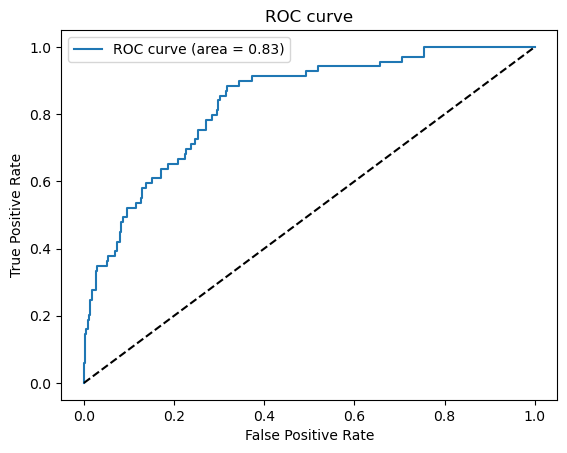

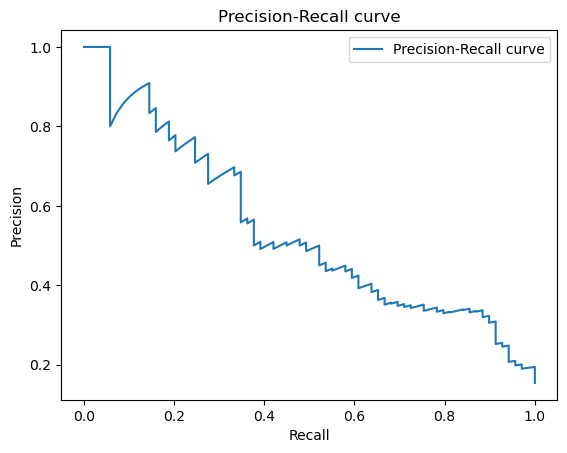

Model: DecisionTreeClassifier
Train Accuracy: 0.9095982142857143, Train F1: 0.5888324873096447
Test Accuracy: 0.8370535714285714, Test F1: 0.21505376344086022
Test ROC-AUC: 0.6949638637145807


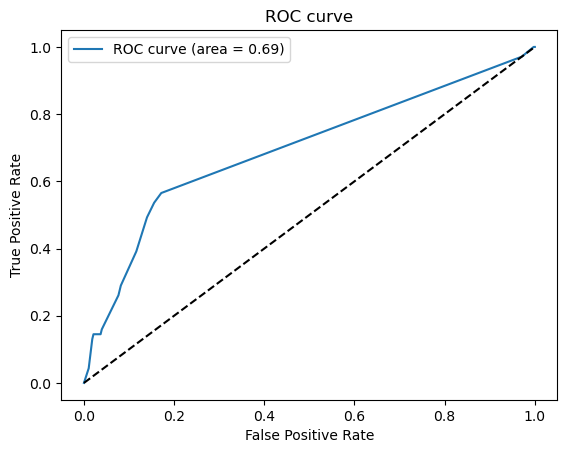

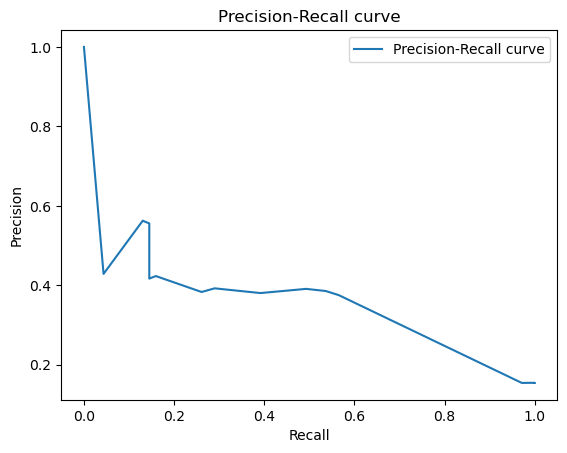

Model: KNeighborsClassifier
Train Accuracy: 0.9079241071428571, Train F1: 0.6024096385542169
Test Accuracy: 0.84375, Test F1: 0.22222222222222224
Test ROC-AUC: 0.7611946005888875


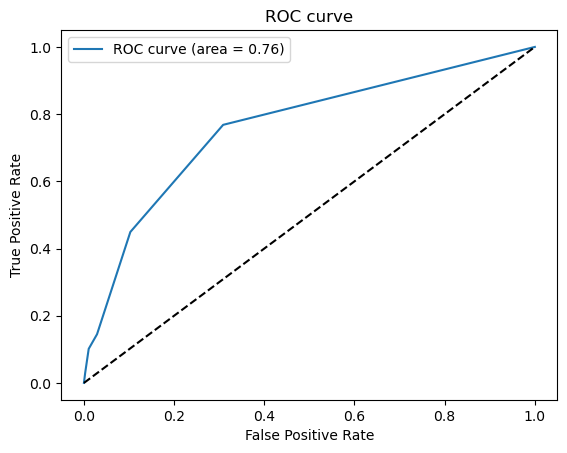

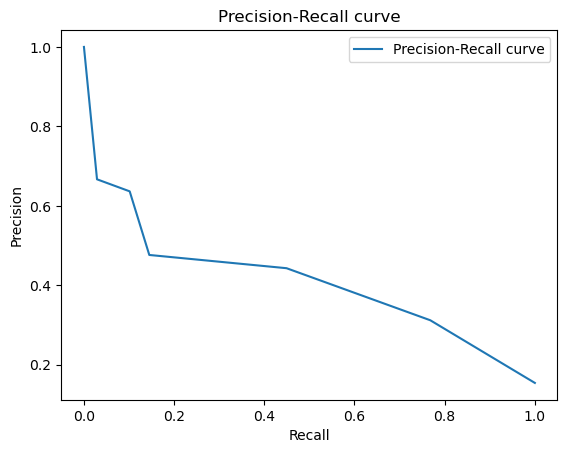

Model: RandomForestClassifier
Train Accuracy: 0.8549107142857143, Train F1: 0.037037037037037035
Test Accuracy: 0.8459821428571429, Test F1: 0.0
Test ROC-AUC: 0.7730105923291652


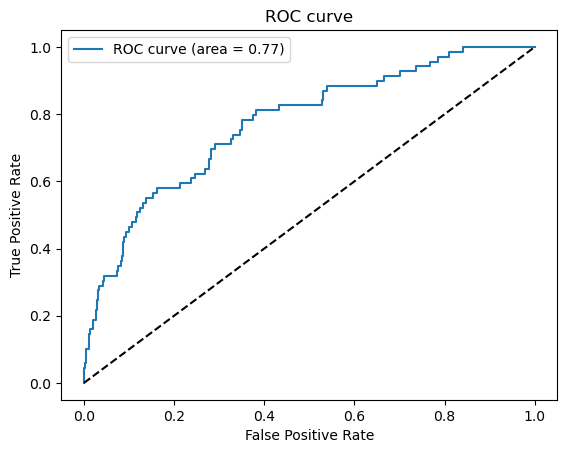

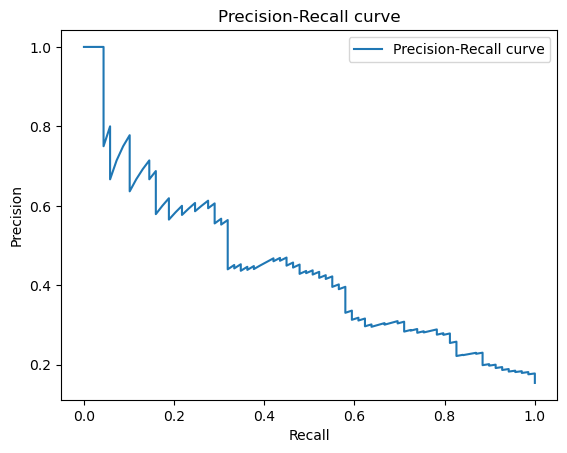

In [41]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, f1_score, roc_curve
import matplotlib.pyplot as plt

# Функция для оценки модели
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики для тренировочной выборки
    accuracy_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    
    # Метрики для тестовой выборки
    accuracy_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    
    # ROC-AUC и PR-кривые для тестовой выборки
    y_test_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_test_prob)
    
    precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
    
    print(f"Model: {model.__class__.__name__}")
    print(f"Train Accuracy: {accuracy_train}, Train F1: {f1_train}")
    print(f"Test Accuracy: {accuracy_test}, Test F1: {f1_test}")
    print(f"Test ROC-AUC: {roc_auc}")
    
    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend(loc='best')
    plt.show()
    
    # PR-кривая
    plt.figure()
    plt.plot(recall, precision, label='Precision-Recall curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve')
    plt.legend(loc='best')
    plt.show()

# Оценка всех моделей
evaluate_model(log_reg, X_train_final, y_train, X_test_final, y_test)
evaluate_model(tree, X_train_final, y_train, X_test_final, y_test)
evaluate_model(knn, X_train_final, y_train, X_test_final, y_test)
evaluate_model(forest, X_train_final, y_train, X_test_final, y_test)


## 4. Сравнение моделей и OneVsRestClassifier

In [42]:
### Сравнение моделей

- **Какая модель справилась лучше с поставленной задачей?**
  - Определяется по наибольшим значениям метрик на тестовой выборке, особенно ROC-AUC и F1-score.
  
- **Имеет ли место переобучение?**
  - Если метрики на тренировочной выборке значительно выше, чем на тестовой, модель переобучена.
  
- **Имеет ли место недообучение?**
  - Если метрики на обеих выборках низкие, модель недообучена.

- **Как можно улучшить метрики моделей?**
  - Попробовать разные гиперпараметры моделей (например, разная глубина дерева, количество соседей и т.д.).
  - Использовать другие алгоритмы и ансамблирование.
  - Применить кросс-валидацию для более точной оценки и выбора гиперпараметров.
  - Увеличить объем тренировочных данных (если возможно).


SyntaxError: invalid syntax (3631460164.py, line 3)

In [43]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

# Создаем синтетические данные для примера с корректными параметрами
X, y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_clusters_per_class=1, n_informative=5, random_state=42)

# Разделяем данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем экземпляр OneVsRestClassifier с логистической регрессией в качестве базового классификатора
clf = OneVsRestClassifier(LogisticRegression())

# Обучаем модель
clf.fit(X_train, y_train)

# Предсказываем классы для тестовой выборки
y_pred = clf.predict(X_test)

# Оцениваем качество модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.905
